## Import Libraries

In [1]:
import os
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.figure as fig
import matplotlib.cm as cm
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, roc_curve


from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

import pickle

import warnings
warnings.filterwarnings('ignore')

In [2]:
dfps_train = []
dfps_test = []

for dirname, _, filenames in os.walk('data/'):
    for filename in filenames:
        if filename.endswith('-training.parquet'):
            dfp = os.path.join(dirname, filename)
            dfps_train.append(dfp)
            print(dfp)
        elif filename.endswith('-testing.parquet'):
            dfp = os.path.join(dirname, filename)
            dfps_test.append(dfp)
            print(dfp)

data/DNS-testing.parquet
data/LDAP-testing.parquet
data/LDAP-training.parquet
data/MSSQL-testing.parquet
data/MSSQL-training.parquet
data/NetBIOS-testing.parquet
data/NetBIOS-training.parquet
data/NTP-testing.parquet
data/Portmap-training.parquet
data/SNMP-testing.parquet
data/Syn-testing.parquet
data/Syn-training.parquet
data/TFTP-testing.parquet
data/UDP-testing.parquet
data/UDP-training.parquet
data/UDPLag-testing.parquet
data/UDPLag-training.parquet


In [3]:
# Common Prefixes in both lists

train_prefixes = [dfp.split('/')[-1].split('-')[0] for dfp in dfps_train]
test_prefixes = [dfp.split('/')[-1].split('-')[0] for dfp in dfps_test]

common_prefixes = list(set(train_prefixes).intersection(test_prefixes))

# Filter the dataframes to only include the common prefixes
dfps_train = [dfp for dfp in dfps_train if dfp.split('/')[-1].split('-')[0] in common_prefixes]
dfps_test = [dfp for dfp in dfps_test if dfp.split('/')[-1].split('-')[0] in common_prefixes]

In [4]:
train_df = pd.concat([pd.read_parquet(dfp) for dfp in dfps_train], ignore_index=True)
test_df = pd.concat([pd.read_parquet(dfp) for dfp in dfps_test], ignore_index=True)

In [5]:
train_df.shape, test_df.shape

((120065, 78), (38973, 78))

In [6]:
train_df.head()

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,17,49,2,0,458.0,0.0,229.0,229.0,229.0,0.0,...,8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NetBIOS
1,17,1,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,...,1480,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,LDAP
2,17,1,2,0,458.0,0.0,229.0,229.0,229.0,0.0,...,14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NetBIOS
3,17,1,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,...,14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,LDAP
4,17,1,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,LDAP


In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120065 entries, 0 to 120064
Data columns (total 78 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Protocol                  120065 non-null  int8   
 1   Flow Duration             120065 non-null  int32  
 2   Total Fwd Packets         120065 non-null  int32  
 3   Total Backward Packets    120065 non-null  int16  
 4   Fwd Packets Length Total  120065 non-null  float32
 5   Bwd Packets Length Total  120065 non-null  float32
 6   Fwd Packet Length Max     120065 non-null  float32
 7   Fwd Packet Length Min     120065 non-null  float32
 8   Fwd Packet Length Mean    120065 non-null  float32
 9   Fwd Packet Length Std     120065 non-null  float32
 10  Bwd Packet Length Max     120065 non-null  float32
 11  Bwd Packet Length Min     120065 non-null  float32
 12  Bwd Packet Length Mean    120065 non-null  float32
 13  Bwd Packet Length Std     120065 non-null  f

In [8]:
train_df.describe()

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Act Data Packets,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,120065.000000,1.200650e+05,120065.000000,120065.000000,120065.000000,1.200650e+05,120065.000000,120065.000000,120065.000000,120065.000000,...,120065.000000,1.200650e+05,1.200650e+05,1.200650e+05,1.200650e+05,1.200650e+05,120065.0,120065.00,120065.0,120065.0
mean,9.847882,2.052619e+07,9.494665,5.229134,793.607300,2.857971e+03,193.468842,124.397636,139.754761,23.783619,...,5.671170,-1.248534e+07,7.801129e+04,7.839449e+04,1.821768e+05,3.275870e+04,6264210.0,1559991.25,7932698.0,4813856.0
std,5.306882,2.995552e+07,356.316717,46.543910,2773.260498,7.459666e+04,362.750641,250.786392,255.366257,89.622917,...,19.933391,1.145488e+08,4.512753e+05,3.853892e+05,8.238682e+05,3.747194e+05,10540597.0,3189277.50,12433032.0,9488153.0
min,0.000000,1.000000e+00,1.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,-1.408238e+09,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.00,0.0,0.0
25%,6.000000,4.110000e+02,2.000000,0.000000,36.000000,0.000000e+00,6.000000,6.000000,6.000000,0.000000,...,1.000000,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.00,0.0,0.0
50%,6.000000,1.096240e+05,4.000000,2.000000,72.000000,1.200000e+01,6.000000,6.000000,6.000000,0.000000,...,3.000000,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.00,0.0,0.0
75%,17.000000,4.531427e+07,10.000000,4.000000,1076.000000,3.600000e+01,388.000000,52.000000,262.511108,7.905694,...,7.000000,2.000000e+01,3.766667e+01,3.323402e+01,1.010000e+02,1.000000e+00,12203672.0,2413746.50,15799887.0,7754443.0
max,17.000000,1.199975e+08,86666.000000,8029.000000,208524.000000,1.289243e+07,3625.000000,2131.000000,2131.000000,1448.583008,...,3888.000000,6.724045e+07,4.050800e+07,1.063756e+07,4.050800e+07,4.050800e+07,117569200.0,69614024.00,117569200.0,117569200.0


## Data Preprocessing

In [9]:
# Check the target distribution of the training data
train_df["Label"].value_counts()

Label
Syn        48840
Benign     42007
UDP        18090
MSSQL       8523
LDAP        1906
NetBIOS      644
UDPLag        55
Name: count, dtype: int64

In [10]:
# Check the target distribution of the testing data
test_df["Label"].value_counts()

Label
Benign           10847
DrDoS_UDP        10420
UDP-lag           8872
DrDoS_MSSQL       6212
DrDoS_LDAP        1440
DrDoS_NetBIOS      598
Syn                533
WebDDoS             51
Name: count, dtype: int64

In [11]:
# Drop the WebDDoS class from the testing data
test_df = test_df[test_df["Label"] != "WebDDoS"]

In [12]:
# Map the labels to the same format
label_mapping = {
    'DrDoS_UDP': 'UDP',
    'UDP-lag': 'UDPLag',
    'DrDoS_MSSQL': 'MSSQL',
    'DrDoS_LDAP': 'LDAP',
    'DrDoS_NetBIOS': 'NetBIOS',
    'Syn': 'Syn',  # Already matches
    'Benign': 'Benign'  # Already matches
}

test_df["Label"] = test_df["Label"].map(label_mapping)

In [13]:
# Check the target distribution of the testing data
test_df["Label"].value_counts()

Label
Benign     10847
UDP        10420
UDPLag      8872
MSSQL       6212
LDAP        1440
NetBIOS      598
Syn          533
Name: count, dtype: int64

In [14]:
# Display the columns of the training data
train_df.columns

Index(['Protocol', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Fwd Packets Length Total',
       'Bwd Packets Length Total', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Packet Length Min', 'Packet Length Max', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Count', 'RST Fla

In [15]:
def grab_col_names(data, cat_th=10, car_th=20):

    # Categorical columns and categorical but high-cardinality columns
    cat_cols = [col for col in data.columns if data[col].dtypes == "O"]
    num_but_cat = [col for col in data.columns if data[col].nunique() < cat_th and data[col].dtypes != "O"]
    high_card_cat_cols = [col for col in data.columns if data[col].nunique() > car_th and data[col].dtypes == "O"]

    # Combine Object type columns and Low-unique-value numeric columns into cat_cols
    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in high_card_cat_cols]

    # Numerical columns excluding those considered as categorical
    num_cols = [col for col in data.columns if data[col].dtypes != "O"]
    num_cols = [col for col in num_cols if col not in num_but_cat]

    # Display information about the dataset
    print(f"Observations: {data.shape[0]}")
    print(f"Variables: {data.shape[1]}")
    print(f"Categorical Columns: {len(cat_cols)}")
    print(f"Numerical Columns: {len(num_cols)}")
    print(f"High Cardinality Categorical Columns: {len(high_card_cat_cols)}")
    print(f"Number but Categorical Columns: {len(num_but_cat)}")
    print("\n")

    return cat_cols, num_cols, high_card_cat_cols

cat_cols, num_cols, high_card_cat_cols = grab_col_names(train_df)
print(f"Catergorical Columns: {cat_cols}")
print(f"Numerical Columns: {num_cols}")
print(f"High Cardinality Categorical Columns: {high_card_cat_cols}")

Observations: 120065
Variables: 78
Categorical Columns: 20
Numerical Columns: 58
High Cardinality Categorical Columns: 0
Number but Categorical Columns: 19


Catergorical Columns: ['Label', 'Protocol', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']
Numerical Columns: ['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd Packets Length Total', 'Bwd Packets Length Total', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT To

In [16]:
# Display the unique values of the categorical columns
for i in cat_cols:
    print(i, train_df[i].unique())

Label ['NetBIOS' 'LDAP' 'Benign' 'MSSQL' 'Syn' 'UDP' 'UDPLag']
Protocol [17  6  0]
Fwd PSH Flags [0 1]
Bwd PSH Flags [0]
Fwd URG Flags [0]
Bwd URG Flags [0]
FIN Flag Count [0]
SYN Flag Count [0 1]
RST Flag Count [0 1]
PSH Flag Count [0]
ACK Flag Count [0 1]
URG Flag Count [0 1]
CWE Flag Count [0 1]
ECE Flag Count [0]
Fwd Avg Bytes/Bulk [0]
Fwd Avg Packets/Bulk [0]
Fwd Avg Bulk Rate [0]
Bwd Avg Bytes/Bulk [0]
Bwd Avg Packets/Bulk [0]
Bwd Avg Bulk Rate [0]


In [17]:
# Display the columns with only one unique value
for i in train_df.columns:
    if train_df[i].nunique() == 1:
        print(i)

Bwd PSH Flags
Fwd URG Flags
Bwd URG Flags
FIN Flag Count
PSH Flag Count
ECE Flag Count
Fwd Avg Bytes/Bulk
Fwd Avg Packets/Bulk
Fwd Avg Bulk Rate
Bwd Avg Bytes/Bulk
Bwd Avg Packets/Bulk
Bwd Avg Bulk Rate


## Missing Values

print(f"Total number of missing values: {train_df.isnull().sum().sum()}")

## Duplicate Rows

In [18]:
print(f"Number of Duplicate Rows: {train_df.duplicated().sum()}")

Number of Duplicate Rows: 3195


In [19]:
# Remove duplicate rows
train_df = train_df.drop_duplicates()

## Exploratory Data Analysis (EDA)

### Categorical Columns

---- Label ----
        Label  Ratio (%)
Label                   
Syn     47246  40.426114
Benign  40980  35.064602
UDP     17795  15.226320
MSSQL    8434   7.216565




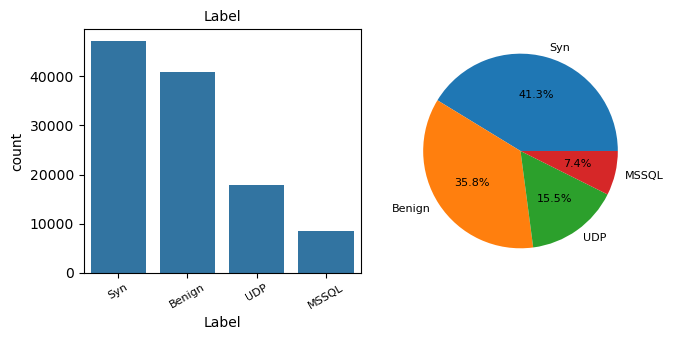

---- Protocol ----
          Protocol  Ratio (%)
Protocol                     
6            74330  63.600582
17           41807  35.772226




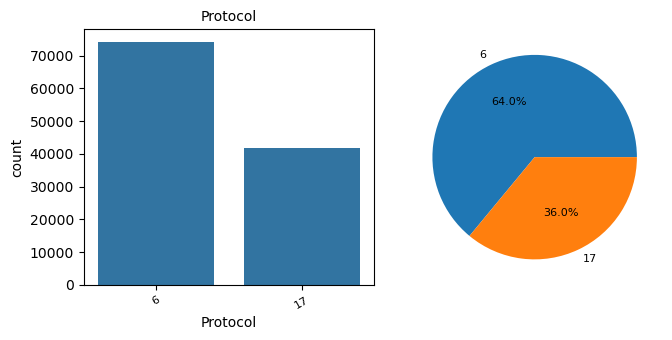

---- SYN Flag Count ----
                SYN Flag Count  Ratio (%)
SYN Flag Count                           
0                       116773  99.917002




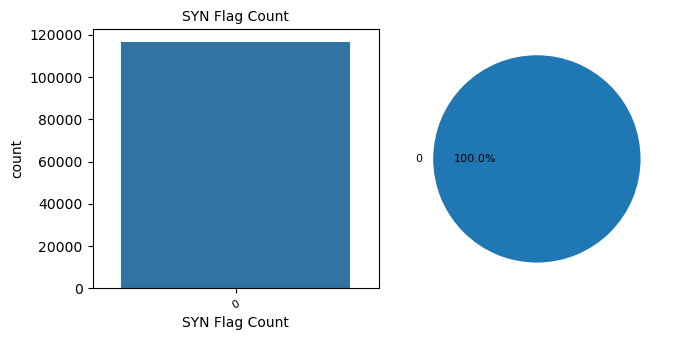

---- ACK Flag Count ----
                ACK Flag Count  Ratio (%)
ACK Flag Count                           
0                        60525  51.788312
1                        56345  48.211688




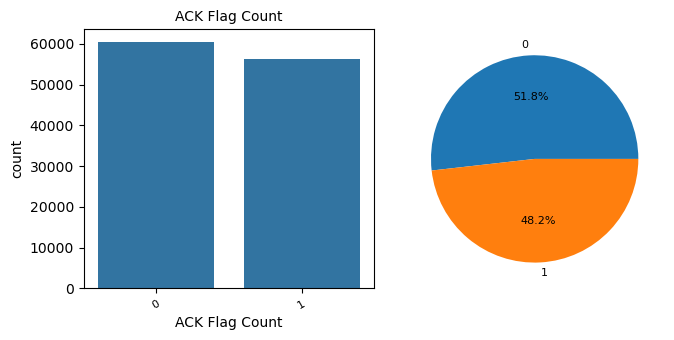

In [20]:
important_cols = ['Label', 'Protocol', 'SYN Flag Count', 'ACK Flag Count']

def cat_summary(data, col, plot=False, threshold=5):
    counts = data[col].value_counts()
    ratios = counts / len(data) * 100

    # Select only important categories
    important = counts[ratios >= threshold]

    print(f"---- {col} ----")
    print(pd.DataFrame({
        col: important,
        "Ratio (%)": ratios[ratios >= threshold]
    }))
    print("\n")

    if plot and len(important) > 0:
        plt.figure(figsize=(7, 3.5))  
        
        # 🔹 Count Plot
        plt.subplot(1, 2, 1)
        sns.countplot(x=col, data=data, order=important.index)
        plt.xticks(rotation=30, fontsize=8)
        plt.title(col, fontsize=10)

        # 🔹 Pie Chart
        plt.subplot(1, 2, 2)
        plt.pie(
            important,
            labels=important.index,
            autopct='%1.1f%%',
            textprops={'fontsize': 8}
        )

        plt.tight_layout()
        plt.show()

for col in important_cols:
    cat_summary(train_df, col, plot=True, threshold=5)

## Numerical Columns

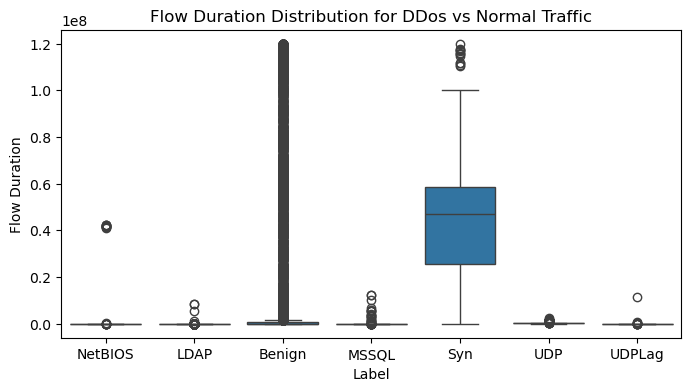

In [21]:
plt.figure(figsize=(8, 4))
sns.boxplot(x="Label", y="Flow Duration", data=train_df)
plt.title("Flow Duration Distribution for DDos vs Normal Traffic")
plt.show()

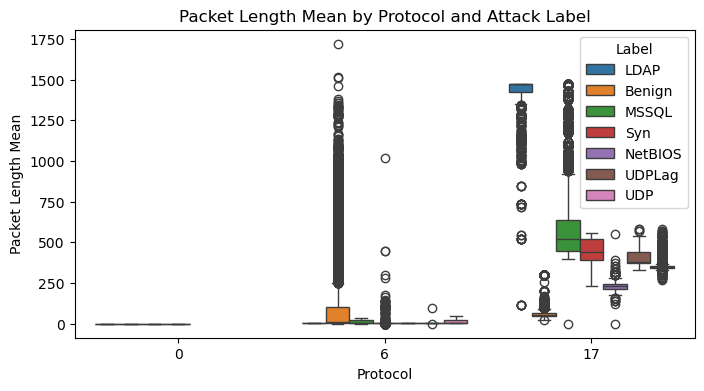

In [22]:
# Boxplot of Packet Length Mean by Protocol and Label
plt.figure(figsize=(8, 4))
sns.boxplot(x="Protocol", y="Packet Length Mean", hue="Label", data=train_df)
plt.title("Packet Length Mean by Protocol and Attack Label")
plt.show()

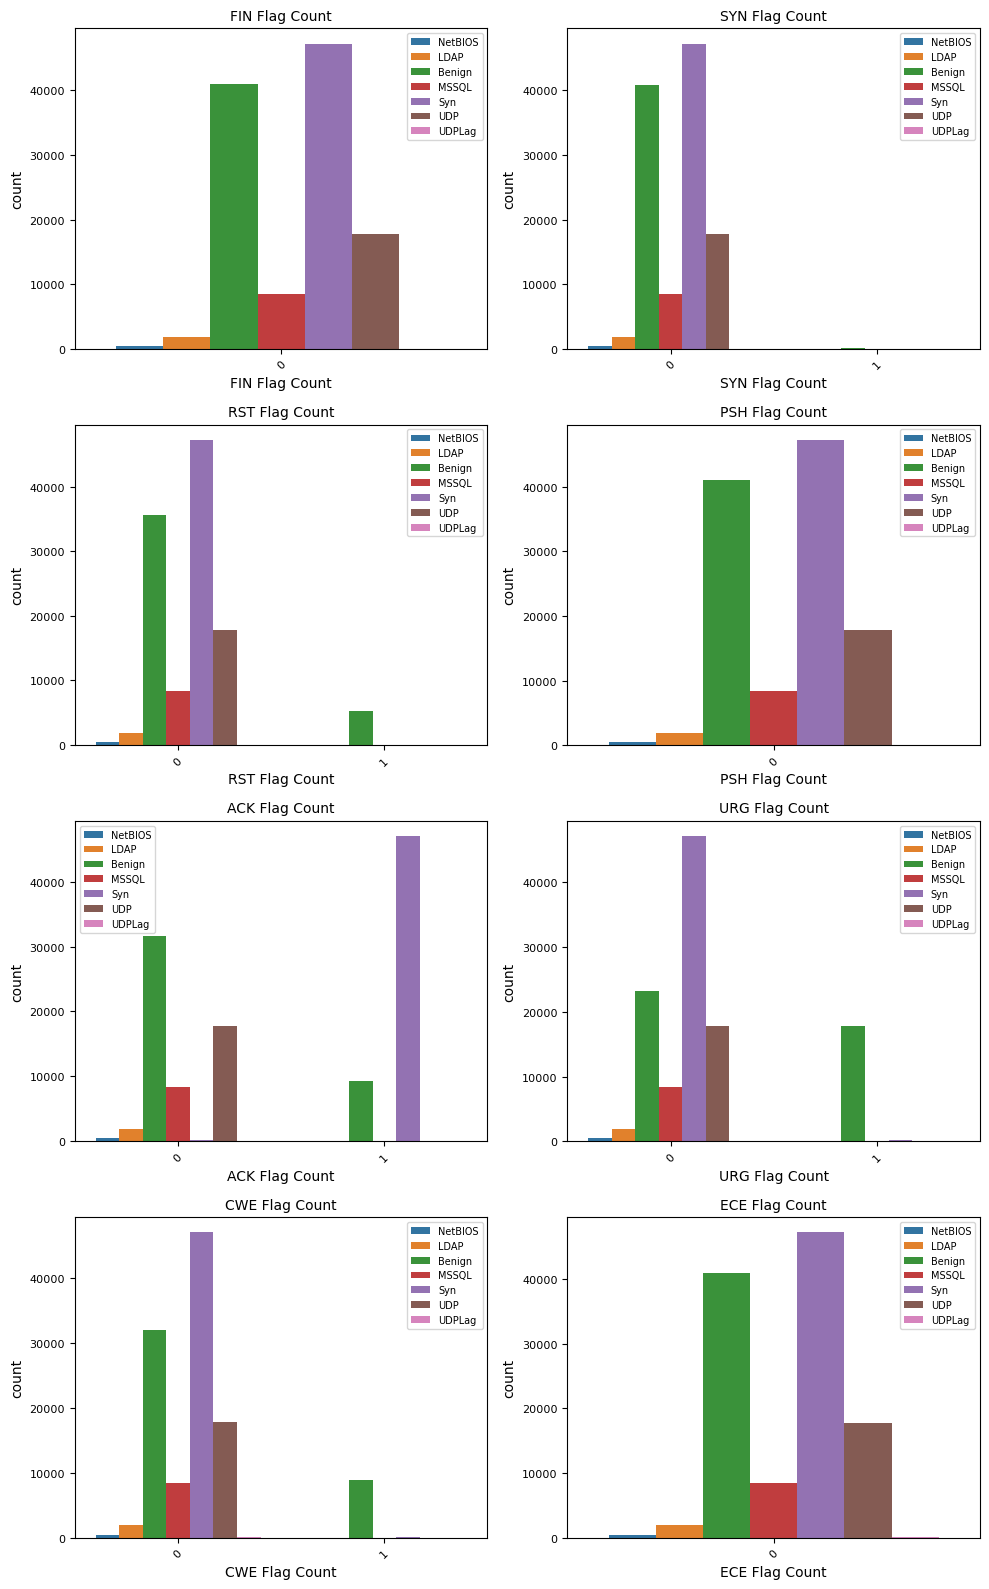

In [23]:
# Counting the number of occurrences of each flag in attack vs normal traffic

flag_cols = [col for col in train_df.columns if "Flag " in col]

n_col = 2  # number of plots per row
n_rows = (len(flag_cols) + n_col - 1) // n_col

fig, axes = plt.subplots(n_rows, n_col, figsize=(10, 4 * n_rows))
axes = axes.flatten()

for i, flag in enumerate(flag_cols):
    sns.countplot(x=flag, hue="Label", data=train_df, ax=axes[i])
    axes[i].set_title(f"{flag}", fontsize=10)
    axes[i].tick_params(axis='x', rotation=45, labelsize=8)
    axes[i].tick_params(axis='y', labelsize=8)
    axes[i].legend(fontsize=7)

# Hide extra empty plots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'The number of requests from different protocols')

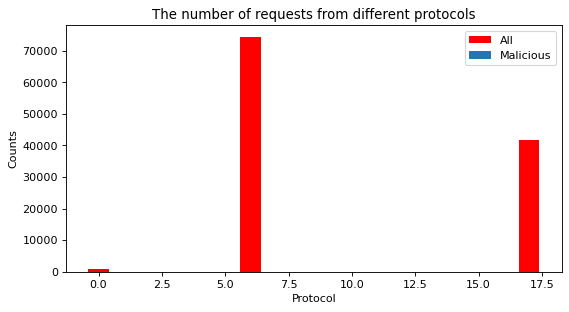

In [24]:
plt.figure(figsize=(8, 4), dpi=80)
plt.bar(list(dict(train_df["Protocol"].value_counts()).keys()), dict(train_df["Protocol"].value_counts()).values(), color='r')
plt.bar(list(dict(train_df[train_df["Label"] == 1]["Protocol"].value_counts()).keys()), dict(train_df[train_df["Label"] == 1]["Protocol"].value_counts()).values(), color='b')

plt.xlabel("Protocol")
plt.ylabel("Counts")
plt.legend(["All", "Malicious"])
plt.title("The number of requests from different protocols")

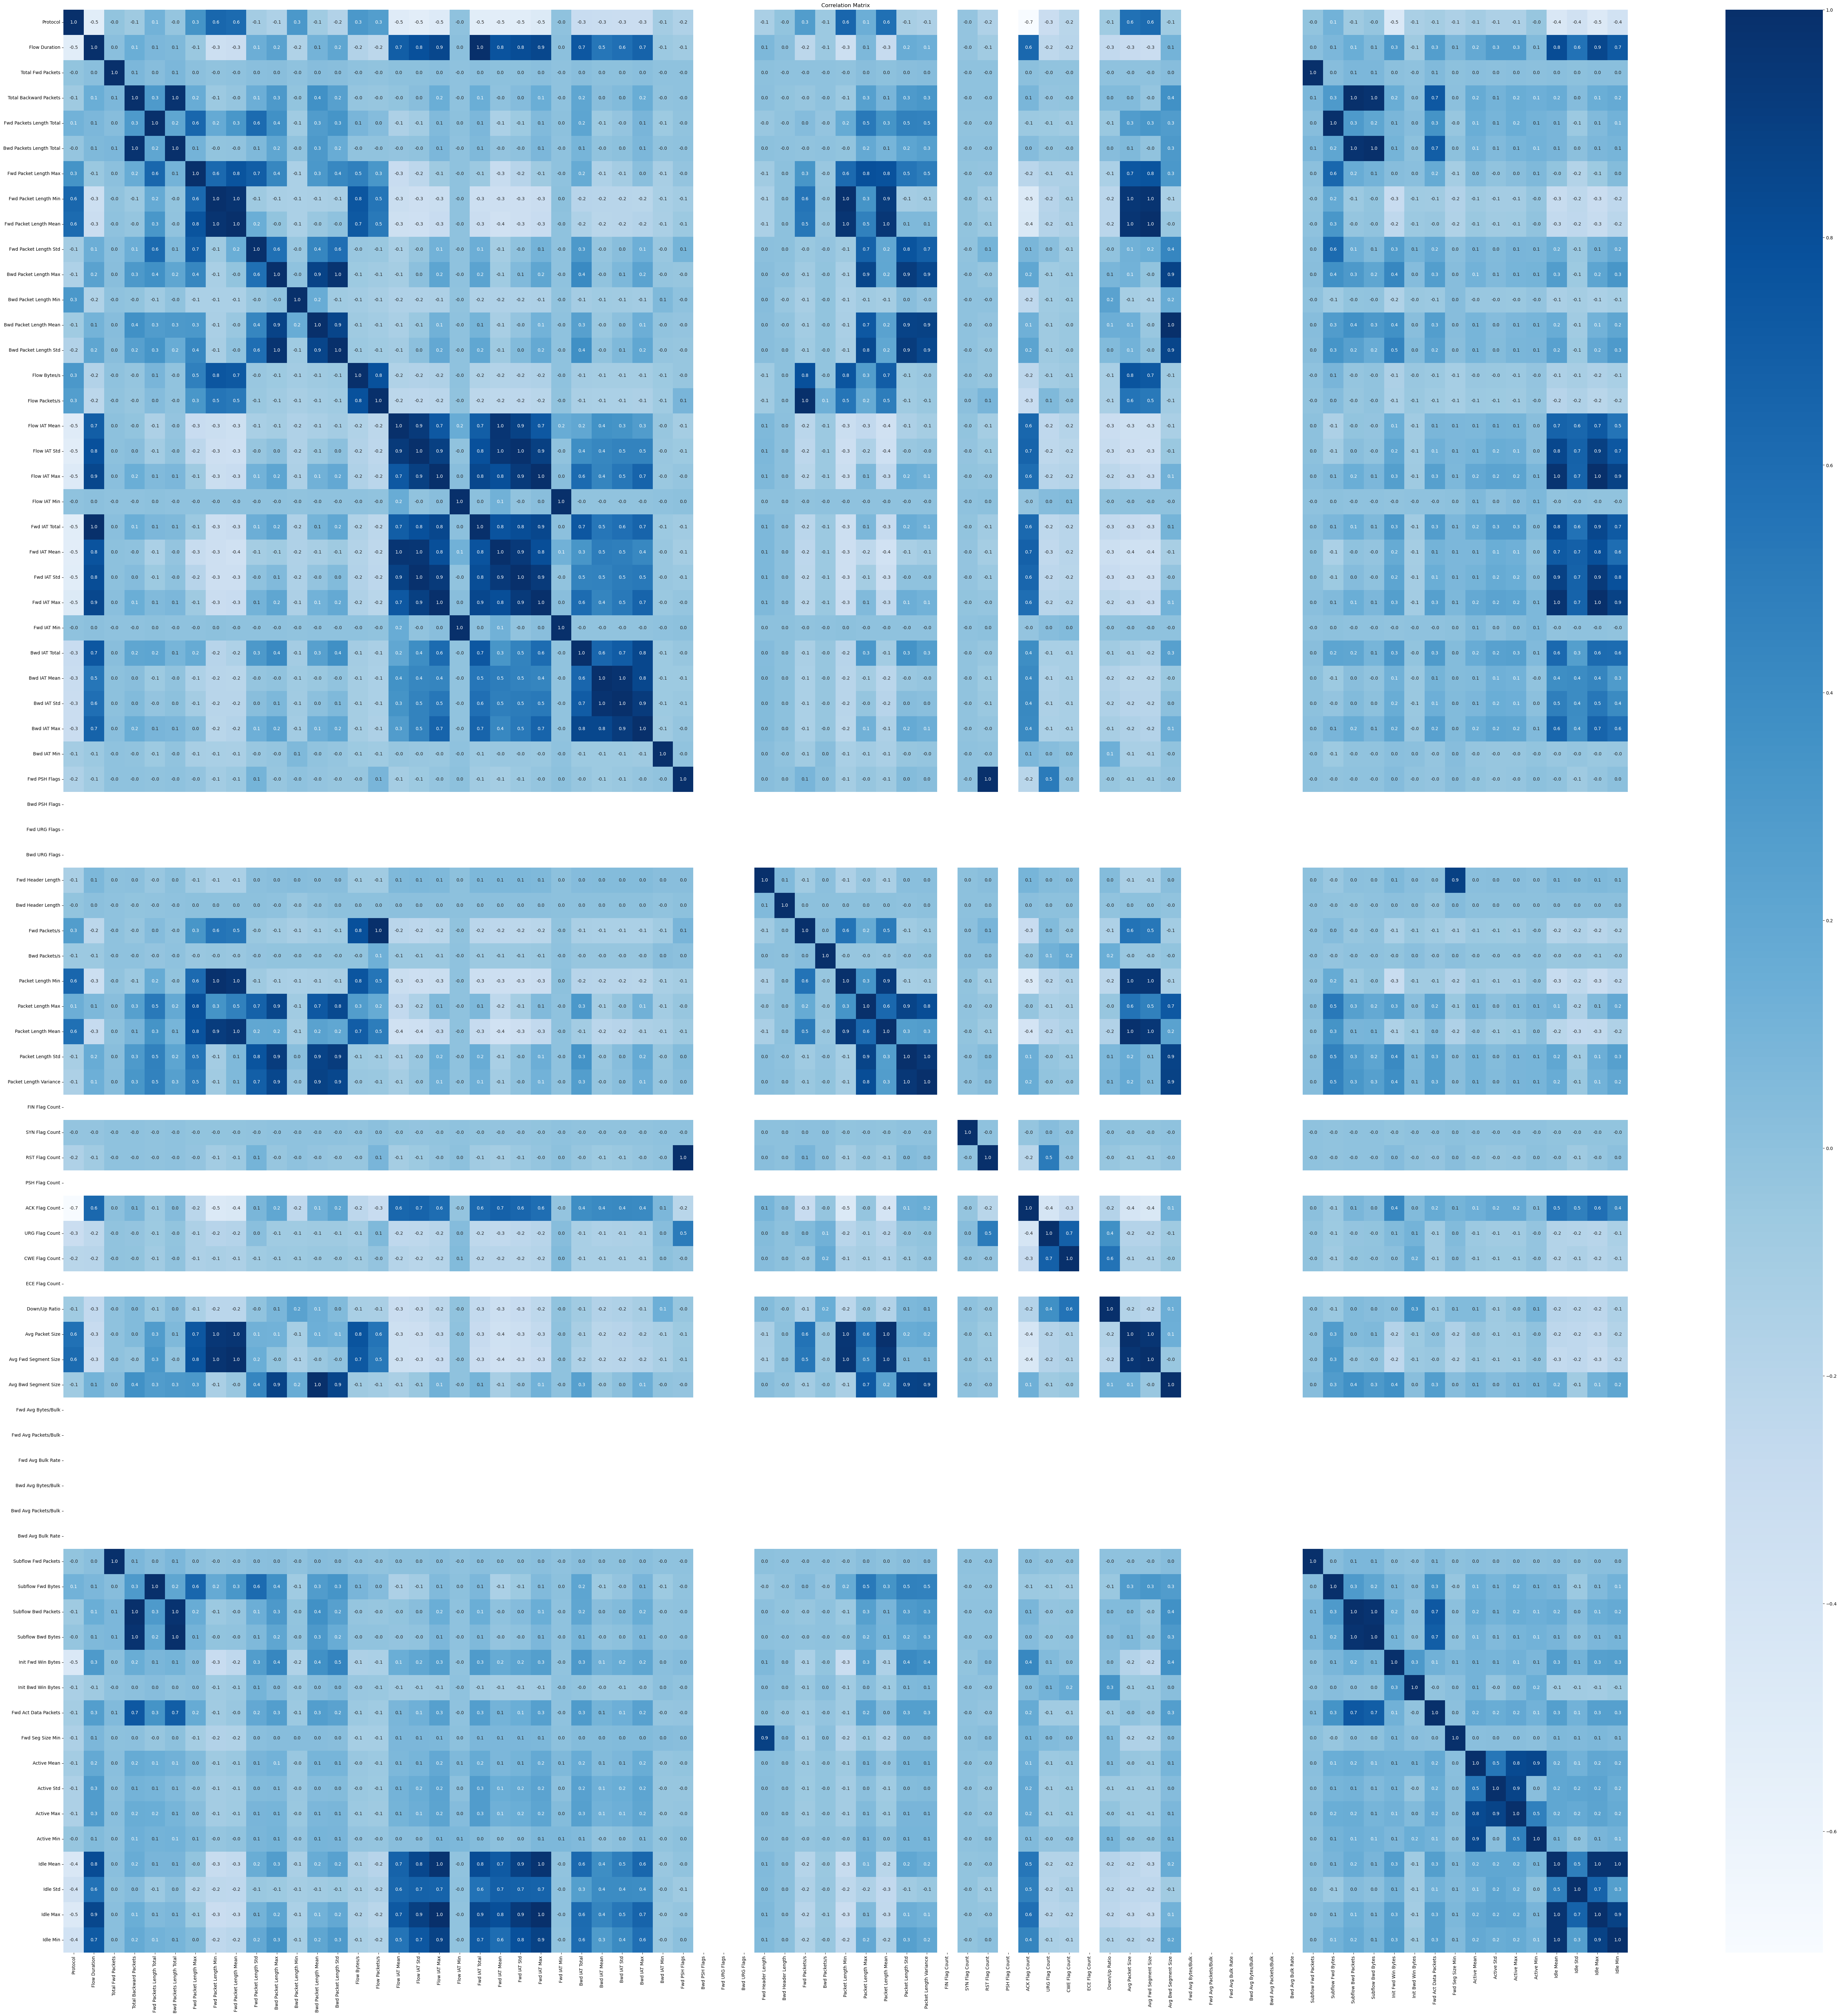

In [25]:
def my_headmap(data, size):
    if size:
        plt.figure(figsize=size)
    sns.heatmap(
        data.corr(),
        annot=True,
        fmt=".1f",
        cmap="Blues",
        annot_kws={"size": 10}
    )
    plt.title("Correlation Matrix")
    plt.show()

n_numeric_cols = len(train_df.select_dtypes(include=[np.number]).columns)

my_headmap(
    train_df.select_dtypes(include=[np.number]),
    size=(n_numeric_cols+1, n_numeric_cols+1)
)

## Feature Engineering

In [26]:
# Features with a single unique value
single_val_cols = [col for col in train_df.columns if train_df[col].nunique() == 1]
single_val_cols

['Bwd PSH Flags',
 'Fwd URG Flags',
 'Bwd URG Flags',
 'FIN Flag Count',
 'PSH Flag Count',
 'ECE Flag Count',
 'Fwd Avg Bytes/Bulk',
 'Fwd Avg Packets/Bulk',
 'Fwd Avg Bulk Rate',
 'Bwd Avg Bytes/Bulk',
 'Bwd Avg Packets/Bulk',
 'Bwd Avg Bulk Rate']

In [27]:
# Remove columns with a single unique value
train_df.drop(single_val_cols, axis=1, inplace = True)
test_df.drop(single_val_cols, axis=1, inplace = True)

In [28]:
# Shape of the dataset after removing columns with a single unique value
train_df.shape, test_df.shape

((116870, 66), (38922, 66))

In [29]:
# Select only numeric columns
numerical_df = train_df.select_dtypes(include=[np.number])

# Calculate the correlation matrix
corr_matrix = numerical_df.corr().abs()

# Generate a boolean mask for the upper triangle
mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)

# Select the upper triangle of the correlation matrix
upper_triangle = corr_matrix.where(mask)

# Find the columns with correlation of 0.8 or higher
high_corr_cols = [col for col in upper_triangle.columns if any(upper_triangle[col] > 0.8)]

# Display the number of highly correlated columns and their names
print(f"Total number of highly correlated columns: {len(high_corr_cols)}")
print("Highly correlated columns are:", high_corr_cols)

Total number of highly correlated columns: 33
Highly correlated columns are: ['Bwd Packets Length Total', 'Fwd Packet Length Mean', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow IAT Std', 'Flow IAT Max', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Std', 'Bwd IAT Max', 'Fwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'RST Flag Count', 'Avg Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes', 'Fwd Seg Size Min', 'Active Max', 'Active Min', 'Idle Mean', 'Idle Max', 'Idle Min']


In [30]:
# Remove highly correlated columns from the dataset
train_df.drop(high_corr_cols, axis=1, inplace=True)
test_df.drop(high_corr_cols, axis=1, inplace=True)

In [31]:
train_df.to_csv("train_data.csv", index=False)
test_df.to_csv("test_data.csv", index=False)

In [32]:
# Shape of the dataset after removing highly correlated columns
train_df.shape, test_df.shape

((116870, 33), (38922, 33))

## Train Test Validation Split

In [33]:
X_train, X_val, y_train, y_val = train_test_split(train_df.drop("Label", axis=1), train_df["Label"], test_size=0.2, random_state=42)
X_test, y_test = test_df.drop("Label", axis=1), test_df["Label"]

In [34]:
X_train.shape, X_val.shape, X_test.shape

((93496, 32), (23374, 32), (38922, 32))

In [35]:
y_train.shape, y_val.shape, y_test.shape

((93496,), (23374,), (38922,))

## Feature Encoding

In [36]:
# Encode the target variable

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_val = le.transform(y_val)
y_test = le.transform(y_test)

# Label mapping for the target variable
label_map = {index: Label for index, Label in enumerate(le.classes_)}

In [37]:
label_map

{0: 'Benign',
 1: 'LDAP',
 2: 'MSSQL',
 3: 'NetBIOS',
 4: 'Syn',
 5: 'UDP',
 6: 'UDPLag'}

## Feature Scaling

In [38]:
# Feature Scaling using MinMaxScaler
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

## Model Training and Evaluation

Training Models:   0%|                                                                           | 0/5 [00:00<?, ?it/s]

Training Random Forest......


Training Models:  20%|█████████████▍                                                     | 1/5 [00:58<03:53, 58.48s/it]

Training KNN......


Training Models:  40%|██████████████████████████▊                                        | 2/5 [01:12<01:36, 32.29s/it]

...

Training Models:  60%|████████████████████████████████████████▏                          | 3/5 [01:43<01:03, 31.85s/it]

Training MLP Classifier......


Training Models:  80%|████████████████████████████████████████████████████             | 4/5 [54:50<21:17, 1277.53s/it]

Training XGBoost......


Training Models: 100%|██████████████████████████████████████████████████████████████████| 5/5 [55:23<00:00, 664.66s/it]


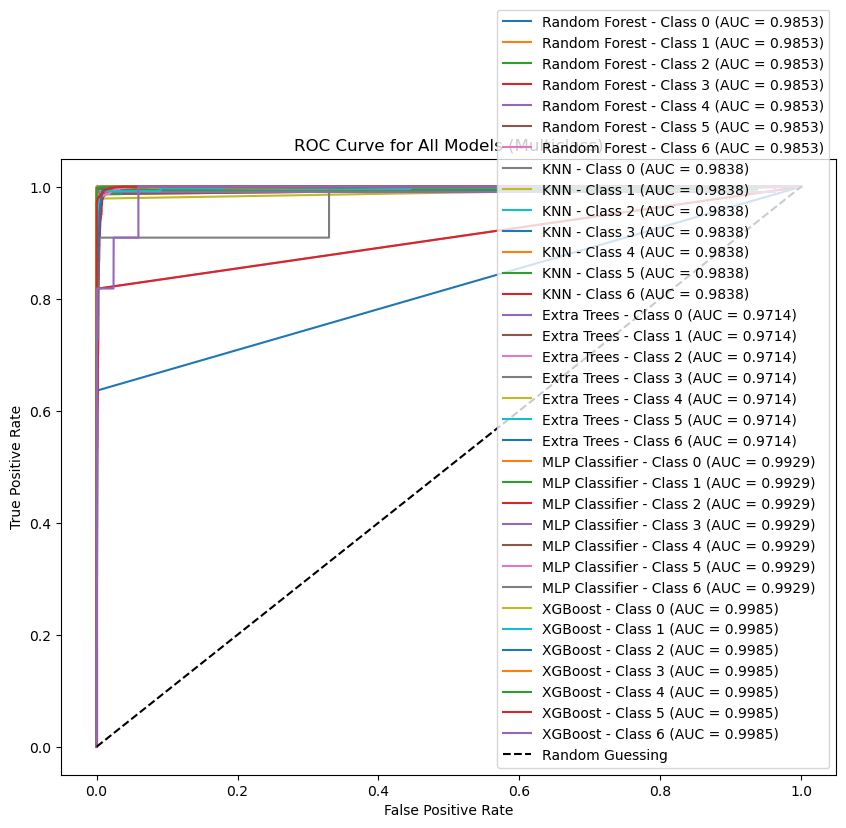

Testing Scores between different models:


In [39]:
# Train and evaluate models
def train_model(X_train, X_test, y_train, y_test):
    # Initialize models
    classifiers = {
        "Random Forest": RandomForestClassifier(),
        "KNN": KNeighborsClassifier(n_neighbors=10),
        "Extra Trees": ExtraTreesClassifier(),
        "MLP Classifier": MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000),
        "XGBoost": XGBClassifier(),
    }

    scores_list = []

    # Initialize plot for ROC curves
    plt.figure(figsize=(10, 8))

    # Train and evaluate models with progress bar
    for name, model in tqdm(classifiers.items(), desc=f"Training Models"):
        print(f"Training {name}......")
        
        # Train model
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # Evaluate predictions for multiclass
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        roc_auc = roc_auc_score(y_test, model.predict_proba(X_test), multi_class="ovr")
        cv_score = np.mean(cross_val_score(model, X_train, y_train, cv=5))

        # ROC curve for the model (for each class)
        y_proba = model.predict_proba(X_test)
        for i in range(len(np.unique(y_train))):
            fpr, tpr, _ = roc_curve(y_test, y_proba[:, i], pos_label=i)
            plt.plot(fpr, tpr, label=f'{name} - Class {i} (AUC = {roc_auc:.4f})')

        # Append scores to the list
        scores_list.append({
            "Model": name,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1 Score": f1,
            "ROC AUC": roc_auc,
            "CV Score": cv_score
        })

    # Finalize the ROC plot
    plt.plot([0, 1], [0, 1], 'k--', label="Random Guessing")  # Diagonal line for random guessing
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve for All Models (Multiclass)')
    plt.legend(loc='lower right')
    plt.show()

    # Create and display the DataFrame of scores
    scores = pd.DataFrame(scores_list)
    return scores

# Run the function
scores = train_model(X_train, X_val, y_train, y_val)
print("Testing Scores between different models:")

In [44]:
def train_model_fast(X_train, X_test, y_train, y_test):
    classifiers = {
        "Random Forest": RandomForestClassifier(n_estimators=100, n_jobs=-1),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "Extra Trees": ExtraTreesClassifier(n_estimators=100, n_jobs=-1),
        "MLP": MLPClassifier(hidden_layer_sizes=(64,), max_iter=200),
        "XGBoost": XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, n_jobs=-1, eval_metric='mlogloss')
    }

    scores_list = []

    for name, model in tqdm(classifiers.items(), desc="Training Models"):
        print(f"Training {name}...")

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

        # Faster ROC AUC
        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(X_test)
            roc_auc = roc_auc_score(y_test, y_proba, multi_class="ovr")
        else:
            roc_auc = 0

        scores_list.append({
            "Model": name,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1 Score": f1,
            "ROC AUC": roc_auc
        })

    return pd.DataFrame(scores_list)

## Display the Accuracy Score Plot

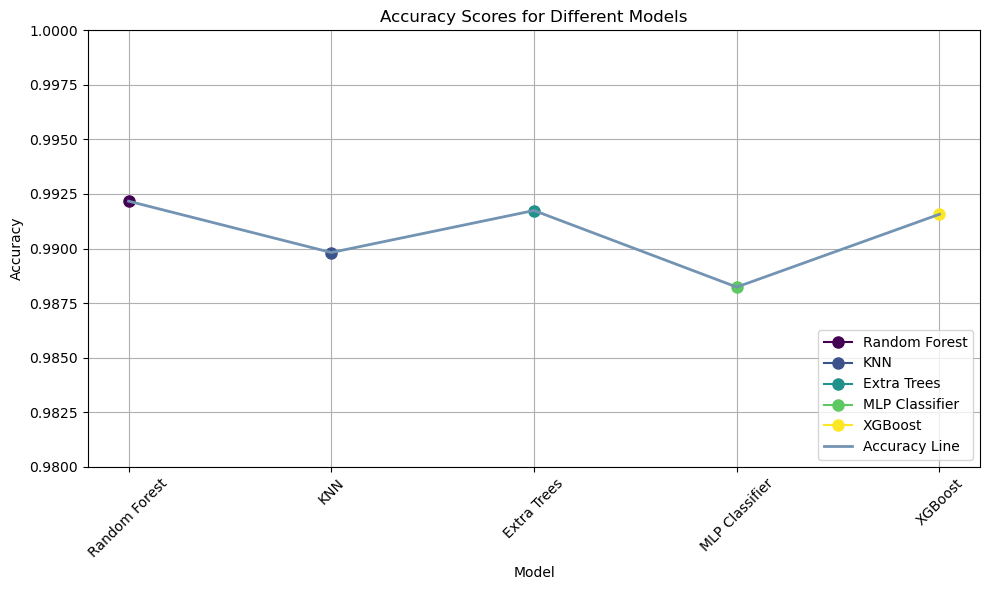

In [40]:
# Assuming 'scores' DataFrame has columns 'Model' and 'Accuracy'
models = scores['Model']
accuracy = scores['Accuracy']

# Generate a color map
colors = cm.viridis(np.linspace(0, 1, len(models)))

# Plotting the accuracy points with color for each model
plt.figure(figsize=(10, 6))
for i, (model, acc) in enumerate(zip(models, accuracy)):
    plt.plot(model, acc, marker='o', color=colors[i], markersize=8, label=model)

# Adding a line that passes through the points
plt.plot(models, accuracy, linestyle='-', color='#7393B3', linewidth=2, label="Accuracy Line")

# Customizing the plot
plt.title("Accuracy Scores for Different Models")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0.98, 1)  # Focus on 96%-100%
plt.xticks(rotation=45)
plt.grid(True)

# Display the plot with legend at the bottom right
handles, labels = plt.gca().get_legend_handles_labels()
unique_labels = dict(zip(labels, handles))  # Remove duplicate labels
plt.legend(unique_labels.values(), unique_labels.keys(), loc="lower right")

# Show the plot
plt.tight_layout()
plt.show()

In [41]:
# Train the best model on the training data
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

# Save the model to a file using pickle
with open('random_forest_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

print("Model saved as 'random_forest_model.pkl'")

Model saved as 'random_forest_model.pkl'
